In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

file = pd.read_excel('C:/Data_/excel/data_jobs_salary_all.xlsx',sheet_name='maaz_1')
file['job_posted_month']=pd.to_datetime(file['job_posted_date']).dt.strftime('%b')


print(file.info())

<class 'pandas.DataFrame'>
RangeIndex: 32672 entries, 0 to 32671
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        32672 non-null  str           
 1   job_title              32672 non-null  str           
 2   job_location           32317 non-null  str           
 3   job_via                32662 non-null  str           
 4   job_schedule_type      32531 non-null  str           
 5   job_work_from_home     32672 non-null  bool          
 6   search_location        32672 non-null  str           
 7   job_posted_date        32672 non-null  datetime64[us]
 8   job_no_degree_mention  32672 non-null  bool          
 9   job_health_insurance   32672 non-null  bool          
 10  job_country            32672 non-null  str           
 11  salary_rate            32672 non-null  str           
 12  salary_year_avg        22036 non-null  float64       
 13  salary_hour_

In [3]:
file

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_posted_month
0,Senior Data Scientist,Senior Data Scientist Data and Analytics Perfo...,"Bennington, NE",via ZipRecruiter,Full-time,False,Sudan,2023-04-24 09:51:15,False,True,Sudan,year,128050.0,NaN,Cox Communications,"['sql', 'python', 'aws', 'pyspark', 'tableau',...",Apr
1,Data Engineer,Data Engineer - MA,"Mesa, AZ",via Indeed,Full-time,False,Georgia,2023-03-13 12:51:23,True,True,United States,year,140000.0,NaN,Worldgate LLC,"['sql', 'nosql', 'java', 'python', 'kafka', 's...",Mar
2,Senior Data Analyst,Supervisory Information Technology Specialist ...,"Alexandria, VA",via ZipRecruiter,Full-time,False,"New York, United States",2023-07-05 07:03:38,True,False,United States,year,156000.0,NaN,National Technical Information Service,NaN,Jul
3,Machine Learning Engineer,Machine Learning Research Scientist,"Pittsburgh, PA",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-13 16:05:41,False,True,United States,year,140000.0,NaN,Bosch Group,"['pytorch', 'tensorflow']",Apr
4,Data Scientist,"Data Scientist, AWS","Irving, TX",via Snagajob,Full-time and Part-time,False,"Texas, United States",2023-10-15 06:02:51,False,False,United States,hour,NaN,39.795002,"Presidio, Inc.","['python', 'r', 'sql', 'c', 'aws', 'gcp', 'big...",Oct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32667,Senior Data Scientist,Senior Data Scientist,"Palo Alto, CA",via Indeed,Full-time,False,"California, United States",2023-08-29 18:05:55,False,True,United States,year,191000.0,NaN,Navan,"['go', 'python', 'sql', 'numpy', 'pandas', 'te...",Aug
32668,Data Analyst,eCommerce Data Analyst | Hybrid Work | W2 Acce...,"Austin, TX",via LinkedIn,Contractor,False,"Texas, United States",2023-03-15 19:01:41,False,False,United States,hour,NaN,42.500000,"TalentBurst, an Inc 5000 company","['python', 'excel']",Mar
32669,Data Scientist,Clinical Data Visualization Specialist - Remote,Anywhere,via ZipRecruiter,Full-time,True,"California, United States",2023-12-18 16:02:34,False,True,United States,hour,NaN,55.000000,Avispa Technology,"['sas', 'sas', 'python']",Dec
32670,Data Analyst,Data Analyst/Report Writer 2,"Austin, TX",via Adzuna,Full-time,False,"Texas, United States",2023-05-04 07:01:58,True,False,United States,hour,NaN,55.000000,My3Tech,"['sas', 'sas', 'word', 'excel', 'sharepoint']",May


In [4]:
#fig, ax=plt.subplots()


#file['job_title_short'].value_counts()
#file['job_schedule_type'].value_counts().head(3)

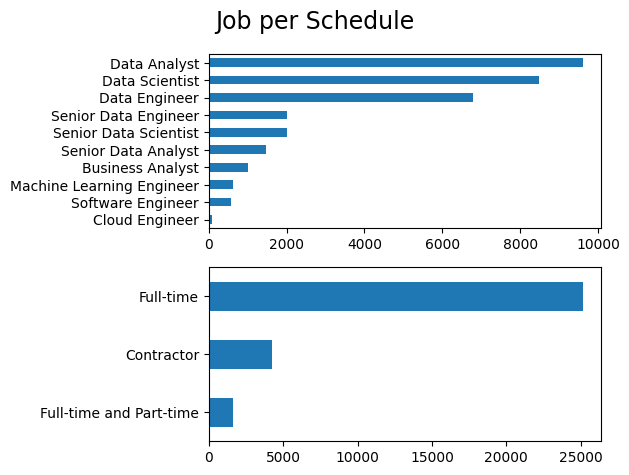

In [5]:
fig, ax=plt.subplots(2,1)

file['job_title_short'].value_counts().plot(kind='barh',ax=ax[0])
file['job_schedule_type'].value_counts().head(3).plot(kind='barh',ax=ax[1])
fig.tight_layout()
ax[0].invert_yaxis()
ax[1].invert_yaxis()
ax[0].set_ylabel('')
ax[1].set_ylabel('')
fig.suptitle('Job per Schedule',fontsize=17)
fig.tight_layout()


In [6]:
def safe_literal_eval(x):
    if pd.isna(x):
        return x
    if isinstance(x, list):  # already a list, skip
        return x
    if not isinstance(x, str) or x.strip() == '':
        return x
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

file['job_skills'] = file['job_skills'].apply(safe_literal_eval)
file_explode=file.explode('job_skills')
file_explode=file_explode.dropna(subset=['job_skills'])
file_explode['job_skills'].value_counts()

job_skills
sql             18500
python          17689
tableau          7046
r                6929
aws              6844
                ...  
debian              1
nuix                1
asp.net core        1
pascal              1
kali                1
Name: count, Length: 221, dtype: int64

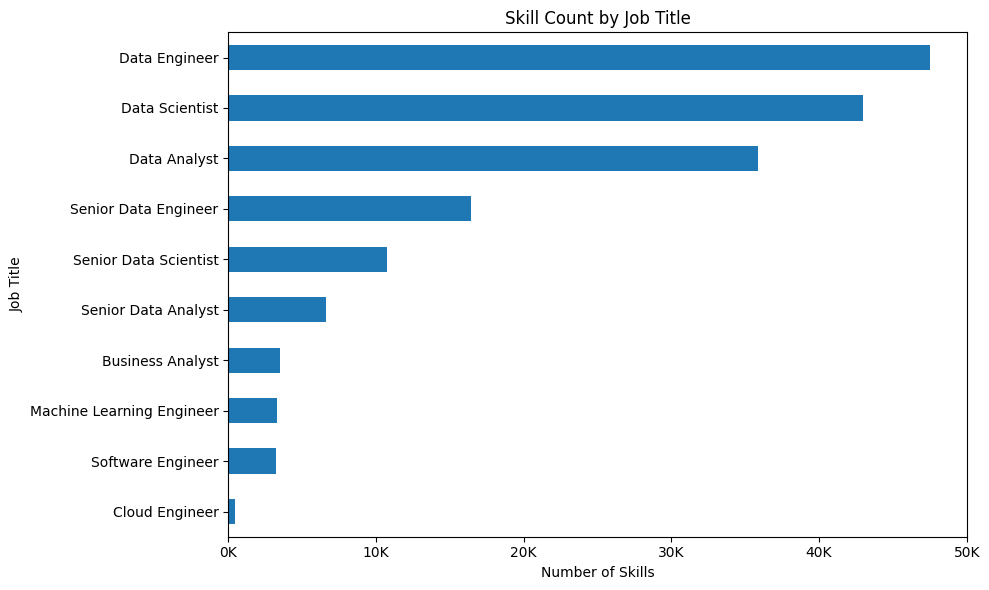

In [22]:
from matplotlib.ticker import FuncFormatter


file_skills=file.explode('job_skills')
skills_counts=file_skills.groupby(['job_title_short']).size()
file_skill_count=skills_counts.reset_index(name='Skill_Count')
file_skill_count=file_skill_count.sort_values(by='Skill_Count',ascending=True)

file_skill_count.plot(kind='barh', x='job_title_short',y='Skill_Count',legend=False,figsize=(10,6))
plt.title('Skill Count by Job Title')
plt.xlabel('Number of Skills')
plt.ylabel('Job Title')
plt.xlim(0,50000)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:,.0f}K'))
plt.tight_layout()
plt.show()





In [26]:
file_skill_count.to_excel('maaaaz.xlsx',index=False)